# Previsão de inadimplência 

### Objetivo: estimar a probabilidade de inadimplência (pagamentos com 5 dias ou mais de atraso) para cada cobrança da base de teste. 

### *Estrutura*

1) carga e qualidade dos dados
2) construção do target 
3) análise exploratória 
4) features
5) modelo e validação 
6) submissão

#### 1 - Carga de dados
 - Separador ';' para os 4 arquivos
 - Conversão das datas e manutenção da 'SAFRA_REF' como texto para a junção com 'ID_CLIENTE'

In [1]:
import pandas as pd

cad = pd.read_csv('data/base_cadastral.csv', sep=';', parse_dates=['DATA_CADASTRO'])

inf = pd.read_csv('data/base_info.csv', sep=';')

desenv = pd.read_csv('data/base_pagamentos_desenvolvimento.csv', sep=';', parse_dates=['DATA_EMISSAO_DOCUMENTO','DATA_PAGAMENTO','DATA_VENCIMENTO'])

test = pd.read_csv('data/base_pagamentos_teste.csv', sep=';', parse_dates=['DATA_EMISSAO_DOCUMENTO','DATA_VENCIMENTO'])

print('cad:', cad.shape)
print('inf:', inf.shape)
print('desenv:', desenv.shape)
print('test:', test.shape)


cad: (1315, 8)
inf: (24401, 4)
desenv: (77414, 7)
test: (12275, 6)


#### 2 - Verificação de qualidade dos dados da base
- Base cadastral de clientes = Apenas clientes únicos (1 cliente por linha)
- Base info = 1 linha = 1 cliente em 1 mês (chave: ID_CLIENTE + SAFRA_REF).
- Base de pagamentos desenv. = 56293 duplicadas - É esperado pois "*Cada linha representa uma 
cobrança mensal para um cliente*" (O dado da base é a cobrança, e um cliente pode ter várias cobranças na mesma safra)
- Base de pagamentos teste = 8836 duplicadas - É esperado pois "*Cada linha 
representa uma cobrança mensal, sem a informação de pagamento.*" (O dado da base é a cobrança, e um cliente pode ter várias cobranças na mesma safra)


In [2]:
print('cad — ID_CLIENTE único?', cad['ID_CLIENTE'].is_unique)
print('inf — duplicatas (ID, SAFRA):', inf.duplicated(['ID_CLIENTE', 'SAFRA_REF']).sum())
print('desenv — duplicatas (ID, SAFRA):', desenv.duplicated(['ID_CLIENTE', 'SAFRA_REF']).sum())
print('test — duplicatas (ID, SAFRA):', test.duplicated(['ID_CLIENTE', 'SAFRA_REF']).sum())

cad — ID_CLIENTE único? True
inf — duplicatas (ID, SAFRA): 0
desenv — duplicatas (ID, SAFRA): 56293
test — duplicatas (ID, SAFRA): 8836


#### 2.1 - Decisão sobre linhas idênticas
- 1 linha 100% duplicada na base de pagamento desenv -> removida (evita peso duplo no treino) 
- 11 na base de pagamentos teste -> mantidas (a submissão exige uma previsão por linha).

In [3]:
print('desenv — linhas iguais:', desenv.duplicated().sum())
print('test — linhas iguais:', test.duplicated().sum())

desenv — linhas iguais: 1
test — linhas iguais: 11


In [4]:
desenv = desenv.drop_duplicates()
print('desenv após limpeza:', desenv.shape)

desenv após limpeza: (77413, 7)


#### 3 - Validação de nulos
- Verifica nas 4 bases para valores nulos/vazios

In [5]:
for nome, df in [('cad', cad), ('inf', inf), ('desenv', desenv), ('test', test)]:
    print(f'--- {nome}')
    print(df.isna().sum())

--- cad
ID_CLIENTE                0
DATA_CADASTRO             0
DDD                     237
FLAG_PF                1249
SEGMENTO_INDUSTRIAL      83
DOMINIO_EMAIL            30
PORTE                    41
CEP_2_DIG                 0
dtype: int64
--- inf
ID_CLIENTE               0
SAFRA_REF                0
RENDA_MES_ANTERIOR     717
NO_FUNCIONARIOS       1252
dtype: int64
--- desenv
ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1169
TAXA                         0
dtype: int64
--- test
ID_CLIENTE                  0
SAFRA_REF                   0
DATA_EMISSAO_DOCUMENTO      0
DATA_VENCIMENTO             0
VALOR_A_PAGAR             131
TAXA                        0
dtype: int64


#### 3.1 - Limpeza dos dados
- As bases fazem uso da lógica: "pessoa física ('X') ou jurídica ('NaN')", limpeza e reajuste para conversão binária ( 1 = pessoa física, 0 = jurídica)


In [6]:
cad['FLAG_PF'].value_counts(dropna=False)

FLAG_PF
NaN    1249
X        66
Name: count, dtype: int64

In [7]:
cad['FLAG_PF'] = (cad['FLAG_PF'] == 'X').astype(int) 

In [8]:
cad['FLAG_PF'].value_counts(dropna=False)

FLAG_PF
0    1249
1      66
Name: count, dtype: int64

#### 4 - Período/cobertura dos dados
- Ambas as bases são complementares (Teste iniciando após desenvolvimento termina)
- A validação do modelo será com base nas safras antigas, realizando a validação nas mais recentes, imitando o cenário do teste
- Validar quantidade de clientes de teste que constam em desenvolvimento

Com o retorno de ~98% conseguimos desenvolver um histórico de pagamento do cliente, pois temos o comportamento de 98% dos clientes da base para estudo

In [9]:
print('desenv:', desenv['SAFRA_REF'].min(), '->', desenv['SAFRA_REF'].max())
print('test:  ', test['SAFRA_REF'].min(), '->', test['SAFRA_REF'].max())
print('% clientes do teste com histórico:', test['ID_CLIENTE'].isin(desenv['ID_CLIENTE']).mean())

desenv: 2018-08 -> 2021-06
test:   2021-07 -> 2021-11
% clientes do teste com histórico: 0.9814256619144602


#### 5 - Construção do target
- Criação da coluna atraso: diferença em dias entre pagamento e vencimento.
- Criação da coluna target: 1 se atraso>=5; 0 else
- Verificação da taxa de inadimplência e o describe do atraso.

In [10]:
desenv['ATRASO'] = (desenv['DATA_PAGAMENTO'] - desenv['DATA_VENCIMENTO']).dt.days

In [11]:
DIAS_INADIMPLENTES=5

desenv['TARGET'] = (desenv['ATRASO'] >= DIAS_INADIMPLENTES).astype(int)
print('Taxa de inadimplência:', desenv['TARGET'].mean())
desenv['ATRASO'].describe()

Taxa de inadimplência: 0.07022076395437458


count    77413.000000
mean        -0.171431
std         25.229640
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: ATRASO, dtype: float64

#### 5.1 - Investigação de min negativo
- min -2661.000000 expõe que existe um registro pago ~7 anos antes do seu vencimento
- Verificar quantidade de retornos negativos
- Avaliando que são 907 casos em uma base de +77 mil, irei mantê-los por aqui e tratá-los quando forem ter peso no cálculo do atraso medio. Por enquanto está controlado com a lógica da coluna target: (1 se atraso>=5; 0 else)

In [12]:
(desenv['ATRASO'] < -30).sum()

np.int64(907)

In [13]:
desenv[desenv['ATRASO'] < -30][['SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'ATRASO']].head(10)

,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,DATA_PAGAMENTO,ATRASO
1427,2018-08,2018-08-25,2018-12-11,2018-09-10,-92
1428,2018-09,2018-09-01,2018-12-29,2018-10-11,-79
1429,2018-09,2018-09-13,2018-12-29,2018-10-11,-79
1704,2018-08,2018-08-29,2018-12-12,2018-09-25,-78
1705,2018-09,2018-09-09,2019-01-13,2018-10-25,-80
1706,2018-09,2018-09-10,2018-12-31,2018-10-10,-82
1826,2018-09,2018-09-02,2019-01-02,2018-10-29,-65
1827,2018-09,2018-09-04,2019-01-02,2018-10-29,-65
1828,2018-09,2018-09-11,2019-01-02,2018-10-29,-65
1860,2018-09,2018-09-04,2019-03-20,2018-09-25,-176


#### 6 - Análise da estrutura de dados
- Análise gráfica da taxa de inadimplência por safra no periodo da base
- Entendimento de comportamentos fora da curva (Começo de 2020)
- Decisão de como lidar com os outliers: Manter no treino, mas será testada empiricamente na seção de modelo (com/sem crise) -> em produção, monitoramento de drift pegaria o próximo choque

<Axes: title={'center': 'Taxa de inadimplência por safra'}, xlabel='SAFRA_REF'>

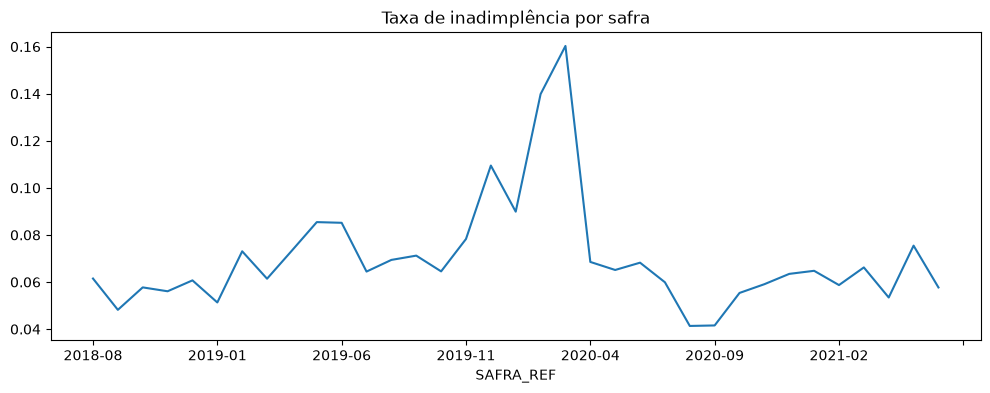

In [14]:
taxa_por_safra = desenv.groupby('SAFRA_REF')['TARGET'].mean()
taxa_por_safra.plot(kind='line', figsize=(12, 4), title='Taxa de inadimplência por safra')

#### 6.1 - Entendimento da inadimplência por perfil
- Análise de inadimplência por porte e segmento
- Entendimento de qual tipo de empresa apresenta maior inadimplencia. Para porte: nan(vazio/não informado) -> Pequeno -> Médio -> Grande e para segmento serviços -> indústria -> nan(vazio/não informado) -> comércio

In [15]:
desenv_perfil = desenv.merge(cad, on='ID_CLIENTE', how='left')
taxa_porte = desenv_perfil.groupby('PORTE', dropna=False)['TARGET'].mean()
print(taxa_porte)

PORTE
GRANDE     0.055112
MEDIO      0.064753
PEQUENO    0.091700
NaN        0.174879
Name: TARGET, dtype: float64


<Axes: title={'center': 'Taxa de inadimplência por porte'}, ylabel='PORTE'>

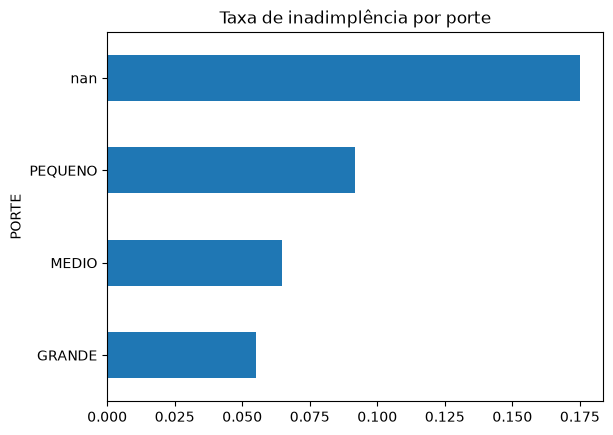

In [16]:

taxa_porte.plot(kind='barh', title='Taxa de inadimplência por porte')

In [17]:
taxa_segmento = desenv_perfil.groupby('SEGMENTO_INDUSTRIAL', dropna=False)['TARGET'].mean()
print(taxa_segmento)

SEGMENTO_INDUSTRIAL
Comércio     0.045895
Indústria    0.076492
Serviços     0.087458
NaN          0.073394
Name: TARGET, dtype: float64


<Axes: title={'center': 'Taxa de inadimplência por segmento'}, ylabel='SEGMENTO_INDUSTRIAL'>

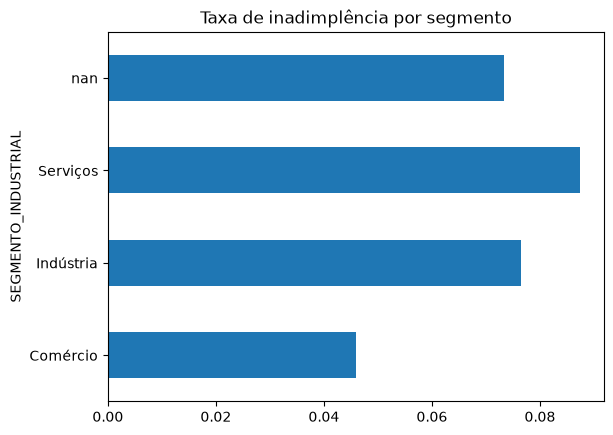

In [18]:
taxa_segmento.plot(kind='barh', title='Taxa de inadimplência por segmento')

#### 7 - Features de comportamento - histórico do cliente
- Verificar comportamento do cliente para entender como ele se comporta antes da cobrança
- No dia da emissão, o desfecho da própria  cobrança e das seguintes ainda não aconteceu, então o histórico só pode usar as cobranças anteriores.
- ATRASO_CLIP: atraso limitado em [-30, 60] dias antes das médias/máximos, para os 907 outliers da seção 5.1 (ex.: -2661) não distorcerem as features.
- Verificação (célula abaixo): a taxa histórica só sobe na cobrança SEGUINTE ao primeiro atraso, nunca na própria linha.

In [19]:
desenv = desenv.sort_values(['ID_CLIENTE', 'DATA_VENCIMENTO'])
desenv['ATRASO_CLIP'] = desenv['ATRASO'].clip(-30, 60)

g = desenv.groupby('ID_CLIENTE')
desenv['HIST_N_COBRANCAS'] = g.cumcount()
desenv['HIST_TAXA_INAD'] = g['TARGET'].transform(lambda s: s.shift(1).expanding().mean())
desenv['HIST_ATRASO_MEDIO'] = g['ATRASO_CLIP'].transform(lambda s: s.shift(1).expanding().mean())
desenv['HIST_ATRASO_MAX'] = g['ATRASO_CLIP'].transform(lambda s: s.shift(1).expanding().max())

In [20]:
um_mau_pagador = desenv[desenv['TARGET'] == 1]['ID_CLIENTE'].iloc[0]
cliente = desenv[desenv['ID_CLIENTE'] == um_mau_pagador][['DATA_VENCIMENTO', 'TARGET', 'HIST_N_COBRANCAS', 'HIST_TAXA_INAD', 'HIST_ATRASO_MEDIO']]
pos = cliente['TARGET'].to_list().index(1)
cliente.iloc[max(0, pos-2):pos+4]

,DATA_VENCIMENTO,TARGET,HIST_N_COBRANCAS,HIST_TAXA_INAD,HIST_ATRASO_MEDIO
33580,2020-01-02,0,125,0.000000,-0.040000
36009,2020-01-06,0,126,0.000000,-0.039683
36010,2020-01-07,1,127,0.000000,-0.039370
36011,2020-01-13,0,128,0.007812,0.031250
36012,2020-01-13,0,129,0.007752,0.031008
36013,2020-01-15,0,130,0.007692,0.030769


#### 8 - Montagem da base de modelagem

- Merge da cadastral por ID_CLIENTE e da info por ID_CLIENTE + SAFRA_REF
- Features de contexto da cobrança:
  1 - PRAZO_DIAS = vencimento - emissão (quanto tempo o cliente teve para pagar)
  - VALOR_SOBRE_RENDA = valor / renda do mês (o mesmo boleto pesa diferente
    conforme o bolso; renda zero vira NaN para não gerar infinito)
  - IDADE_CADASTRO_DIAS = safra - data de cadastro (tempo de relacionamento)
- Nulos (renda, funcionários, valor) são mantidos como NaN

In [21]:
desenv = desenv.merge(cad, on='ID_CLIENTE', how='left')
desenv = desenv.merge(inf, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
print(desenv.shape)

(77413, 23)


In [22]:
desenv['PRAZO_DIAS'] = (desenv['DATA_VENCIMENTO'] - desenv['DATA_EMISSAO_DOCUMENTO']).dt.days
renda_valida = desenv['RENDA_MES_ANTERIOR'].where(desenv['RENDA_MES_ANTERIOR'] > 0)
desenv['VALOR_SOBRE_RENDA'] = desenv['VALOR_A_PAGAR'] / renda_valida

safra_dt = pd.to_datetime(desenv['SAFRA_REF'], format='%Y-%m')
desenv['IDADE_CADASTRO_DIAS'] = (safra_dt - desenv['DATA_CADASTRO']).dt.days

#### 9 - Modelo: baseline e validação out-of-time
- Corte temporal (decisão da seção 4): treino até 2020-12, validação de 2021-01 a 2021-06 (as 6 safras antes do teste)
- Métrica AUC = mede se o score ordena bem o risco (0.5 = moeda, 1.0 = perfeito). PR-AUC de apoio por conta do desbalanceamento de ~7%
- Baseline = ordenar pela taxa histórica do cliente. Se o modelo não superar essa régua, não se justifica
- Modelo LightGBM = trata nulos e categóricas nativamente (decisões das seções 3 e 6.1) e é padrão de mercado em crédito

In [23]:
FEATURES_NUM = ['VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
                'VALOR_SOBRE_RENDA', 'IDADE_CADASTRO_DIAS', 'FLAG_PF',
                'HIST_N_COBRANCAS', 'HIST_TAXA_INAD', 'HIST_ATRASO_MEDIO', 'HIST_ATRASO_MAX']
FEATURES_CAT = ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'DDD']
FEATURES = FEATURES_NUM + FEATURES_CAT

for c in FEATURES_CAT:
    desenv[c] = desenv[c].astype('category')

corte = '2021-01'
treino = desenv[desenv['SAFRA_REF'] < corte]
valid  = desenv[desenv['SAFRA_REF'] >= corte]

print('treino:', treino.shape, '| taxa:', treino['TARGET'].mean().round(3))
print('valid :', valid.shape,  '| taxa:', valid['TARGET'].mean().round(3))


treino: (63146, 26) | taxa: 0.072
valid : (14267, 26) | taxa: 0.063


In [24]:
from sklearn.metrics import roc_auc_score, average_precision_score

p_baseline = valid['HIST_TAXA_INAD'].fillna(treino['TARGET'].mean())
print('baseline — AUC:', round(roc_auc_score(valid['TARGET'], p_baseline), 4))
print('baseline — PR-AUC:', round(average_precision_score(valid['TARGET'], p_baseline), 4))


baseline — AUC: 0.8959
baseline — PR-AUC: 0.457


In [25]:
from lightgbm import LGBMClassifier

modelo = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                        random_state=42, verbose=-1)
modelo.fit(treino[FEATURES], treino['TARGET'])

p_valid = modelo.predict_proba(valid[FEATURES])[:, 1]
print('LightGBM — AUC:', round(roc_auc_score(valid['TARGET'], p_valid), 4))
print('LightGBM — PR-AUC:', round(average_precision_score(valid['TARGET'], p_valid), 4))


LightGBM — AUC: 0.9408
LightGBM — PR-AUC: 0.6227


- O LightGBM supera o baseline nas duas métricas -> as features além do histórico agregam valor real

#### 9.1 - Experimento das safras da crise (promessa da seção 6)
- Treinar com e sem as safras 2020-02 a 2020-04 e comparar na mesma validação

In [26]:
safras_crise = ['2020-02', '2020-03', '2020-04']
treino_sem_crise = treino[~treino['SAFRA_REF'].isin(safras_crise)]

modelo_sem_crise = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                                  random_state=42, verbose=-1)
modelo_sem_crise.fit(treino_sem_crise[FEATURES], treino_sem_crise['TARGET'])
p_sem_crise = modelo_sem_crise.predict_proba(valid[FEATURES])[:, 1]

print('treino COM crise:', len(treino), 'linhas | AUC:', round(roc_auc_score(valid['TARGET'], p_valid), 4))
print('treino SEM crise:', len(treino_sem_crise), 'linhas | AUC:', round(roc_auc_score(valid['TARGET'], p_sem_crise), 4))


treino COM crise: 63146 linhas | AUC: 0.9408
treino SEM crise: 57172 linhas | AUC: 0.9448


- Resultado: sem a crise validou levemente melhor (AUC 0.9448 vs 0.9408) -> modelo final treinado sem essas safras
- Diferença pequena: com uma única janela de validação pode ser ruído. Em produção, repetir o teste em mais janelas

#### 9.2 - Importância das features

<Axes: title={'center': 'Importância das features (nº de divisões nas árvores)'}>

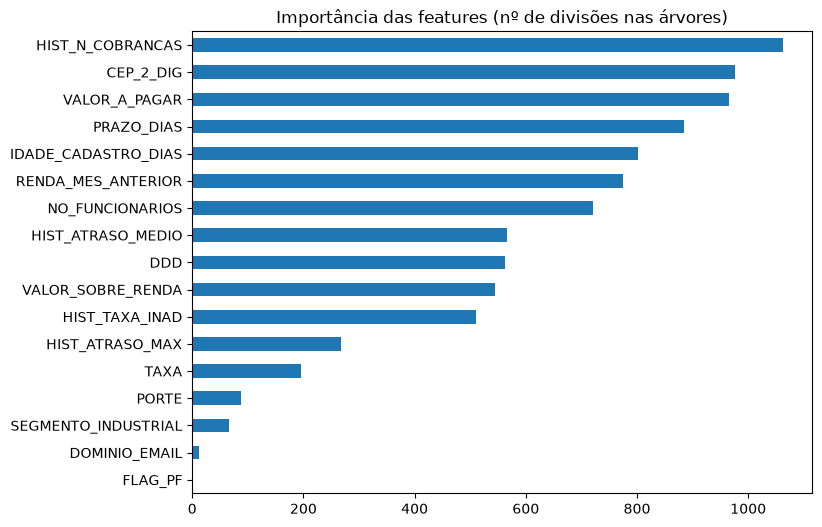

In [27]:
importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
importancias.plot(kind='barh', figsize=(8, 6), title='Importância das features (nº de divisões nas árvores)')


- Comportamento histórico, capacidade de pagamento (renda, valor sobre renda) e perfil/região dividem o topo. Nenhuma feature domina sozinha

#### 10 - Submissão
- Modelo final retreinado com todo o desenvolvimento menos as safras da crise (decisão da seção 9.1)
- Histórico do teste = agregado de todo o desenvolvimento (termina em 2021-06, antes do teste começar -> sem vazamento)
- Uma previsão por linha da base de teste, na ordem original, separador ';'

In [28]:
hist_cliente = desenv.groupby('ID_CLIENTE').agg(
    HIST_N_COBRANCAS=('TARGET', 'size'),
    HIST_TAXA_INAD=('TARGET', 'mean'),
    HIST_ATRASO_MEDIO=('ATRASO_CLIP', 'mean'),
    HIST_ATRASO_MAX=('ATRASO_CLIP', 'max'),
).reset_index()

test['_ORDEM'] = range(len(test))
test = test.merge(hist_cliente, on='ID_CLIENTE', how='left')
test = test.merge(cad, on='ID_CLIENTE', how='left')
test = test.merge(inf, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

test['PRAZO_DIAS'] = (test['DATA_VENCIMENTO'] - test['DATA_EMISSAO_DOCUMENTO']).dt.days
renda_valida_teste = test['RENDA_MES_ANTERIOR'].where(test['RENDA_MES_ANTERIOR'] > 0)
test['VALOR_SOBRE_RENDA'] = test['VALOR_A_PAGAR'] / renda_valida_teste
safra_dt_teste = pd.to_datetime(test['SAFRA_REF'], format='%Y-%m')
test['IDADE_CADASTRO_DIAS'] = (safra_dt_teste - test['DATA_CADASTRO']).dt.days

for c2 in FEATURES_CAT:
    test[c2] = test[c2].astype('category').cat.set_categories(desenv[c2].cat.categories)

print('teste com features:', test.shape)

teste com features: (12275, 23)


In [29]:
base_final = desenv[~desenv['SAFRA_REF'].isin(safras_crise)]

modelo_final = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                              random_state=42, verbose=-1)
modelo_final.fit(base_final[FEATURES], base_final['TARGET'])

test['PROBABILIDADE_INADIMPLENCIA'] = modelo_final.predict_proba(test[FEATURES])[:, 1]

submissao = test.sort_values('_ORDEM')[['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA']]

assert len(submissao) == 12275
assert submissao['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all()
assert submissao['PROBABILIDADE_INADIMPLENCIA'].notna().all()

submissao.to_csv('submissao_case.csv', sep=';', index=False)
print(submissao.head())
print('linhas:', len(submissao))
print('probabilidade média:', round(float(submissao['PROBABILIDADE_INADIMPLENCIA'].mean()), 4))

            ID_CLIENTE SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
0  5058298901476893676   2021-07                     0.001960
1   274692171162531764   2021-07                     0.009139
2   274692171162531764   2021-07                     0.010013
3   274692171162531764   2021-07                     0.010013
4   465309249432033993   2021-07                     0.001137
linhas: 12275
probabilidade média: 0.0432


#### 11 - Conclusão
- Target com a regra exata do case (atraso >= 5 dias)
- Features de comportamento sem informação do futuro (shift + expanding), mais perfil, renda e contexto da cobrança
- Validação out-of-time imitando o cenário real e baseline como régua
- Decisão sobre as safras da crise por experimento, não por opinião
- Próximos passos: monitorar drift por safra (PSI), retreinar com safras novas, features de janela (3/6/12 meses)
- Fontes consultadas: documentação do pandas, do LightGBM e do scikit-learn